#Understanding Core Problem
Delhivery needs to:

Clean and process raw pipeline data

Engineer meaningful features


Enable the data science team to build forecasting models



In [91]:
# Start with clear problem framing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [92]:
url="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/551/original/delhivery_data.csv?1642751181"

In [93]:
df=pd.read_csv(url)
df.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


In [94]:
df.shape

(144867, 24)

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

In [96]:
df['od_end_time']

,od_end_time
0,2018-09-20 04:47:45.236797
1,2018-09-20 04:47:45.236797
2,2018-09-20 04:47:45.236797
3,2018-09-20 04:47:45.236797
4,2018-09-20 04:47:45.236797
...,...
144862,2018-09-20 23:32:09.618069
144863,2018-09-20 23:32:09.618069
144864,2018-09-20 23:32:09.618069
144865,2018-09-20 23:32:09.618069


In [97]:
df['trip_creation_time'] = pd.to_datetime(df['trip_creation_time'])
df['od_start_time']       = pd.to_datetime(df['od_start_time'])
df['od_end_time']         = pd.to_datetime(df['od_end_time'])


In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   data                            144867 non-null  object        
 1   trip_creation_time              144867 non-null  datetime64[ns]
 2   route_schedule_uuid             144867 non-null  object        
 3   route_type                      144867 non-null  object        
 4   trip_uuid                       144867 non-null  object        
 5   source_center                   144867 non-null  object        
 6   source_name                     144574 non-null  object        
 7   destination_center              144867 non-null  object        
 8   destination_name                144606 non-null  object        
 9   od_start_time                   144867 non-null  datetime64[ns]
 10  od_end_time                     144867 non-null  datetim

#Filling Nan Values
Since they are only present in Source_name and destination_name
I am replacing them with unknown

In [99]:
df['source_name'] = df['source_name'].fillna("Unknown")
df['destination_name'] = df['destination_name'].fillna("Unknown")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   data                            144867 non-null  object        
 1   trip_creation_time              144867 non-null  datetime64[ns]
 2   route_schedule_uuid             144867 non-null  object        
 3   route_type                      144867 non-null  object        
 4   trip_uuid                       144867 non-null  object        
 5   source_center                   144867 non-null  object        
 6   source_name                     144867 non-null  object        
 7   destination_center              144867 non-null  object        
 8   destination_name                144867 non-null  object        
 9   od_start_time                   144867 non-null  datetime64[ns]
 10  od_end_time                     144867 non-null  datetim

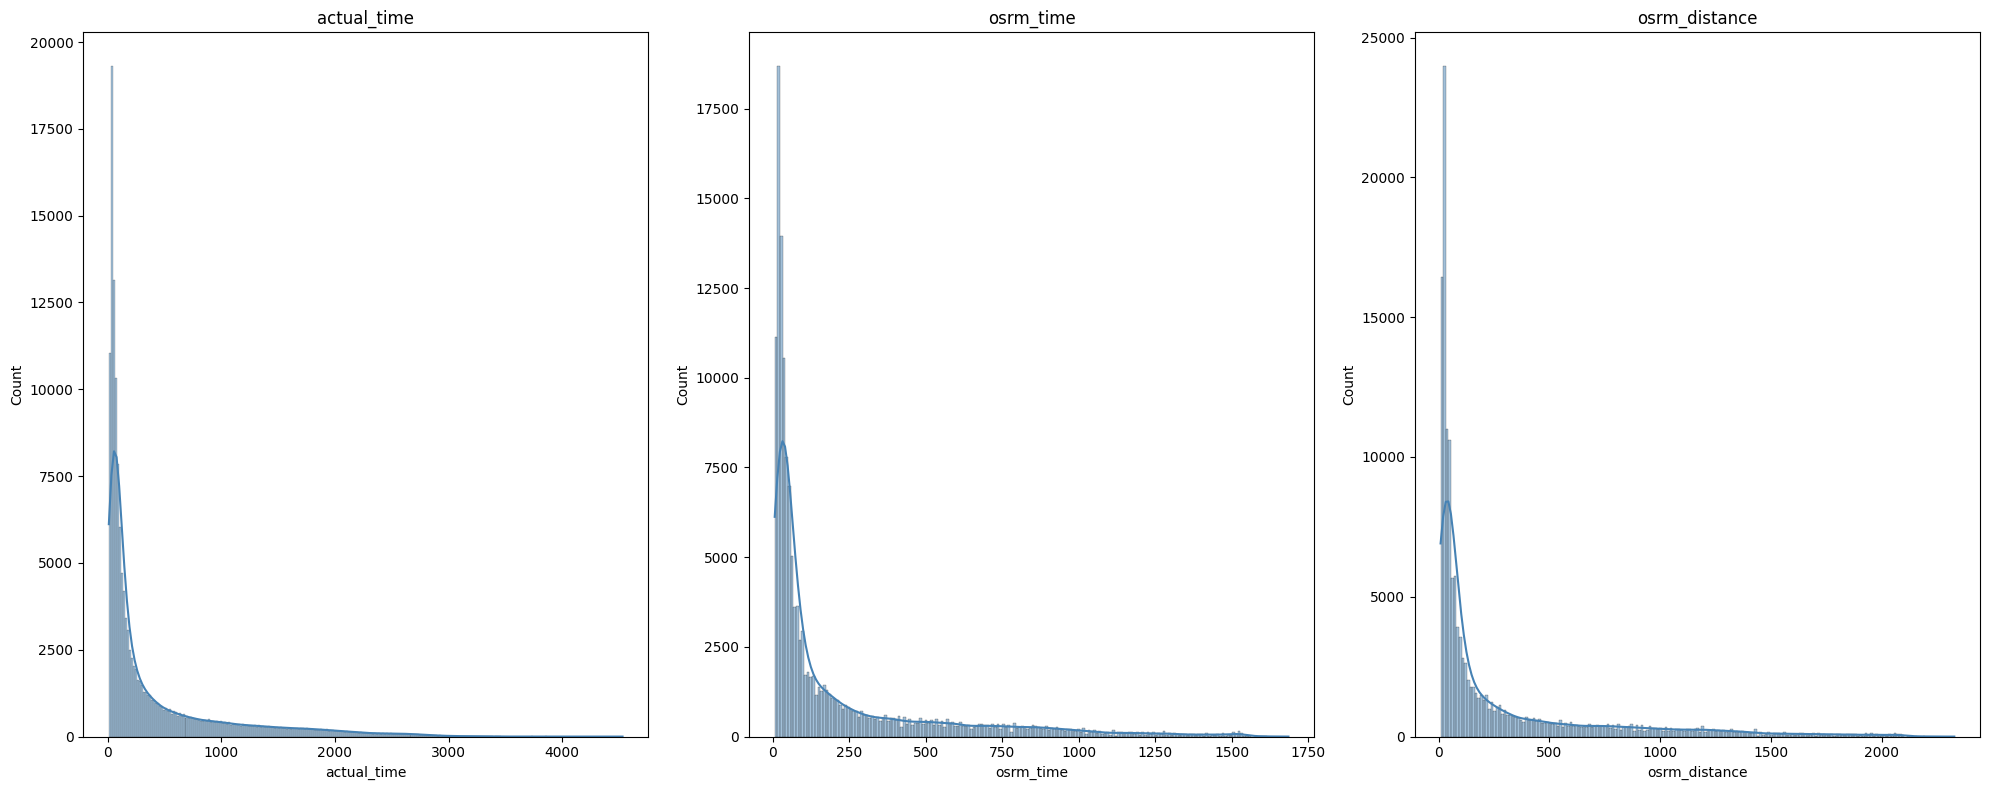

In [100]:
fig, axes = plt.subplots(1, 3, figsize=(20,8))
cols = ['actual_time','osrm_time','osrm_distance']
for ax, col in zip(axes.flatten(), cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()


#total_actual_time (0 to ~4500)

The spike near zero + extreme tail means most trips complete quickly, but a handful take extraordinarily long
The tail stretching to 4500 is a red flag — these are almost certainly data errors or unresolved trips (packages never marked as delivered, or timestamp corruption)

The gap between ~2750 and 4500 is nearly empty — confirming these extreme values are isolated outliers, not a second population

#total_osrm_time (0 to ~1750)

Much shorter tail than actual_time — OSRM never predicts 175,000 because it only calculates road travel

The fact that actual goes to 175k while OSRM caps at 80k means some trips accumulated ~95,000 units of non-travel time — sitting at hubs, delays, system issues

#total_osrm_distance (0 to ~2000)

Similar shape to osrm_time, confirming time and distance remain correlated after aggregation

The near-zero spike is even more pronounced here — majority of trips are short-distance last-mile






#Outlier treatment is mandatory — IQR capping will significantly affect all three columns
The data mixes two populations — short Carting trips (the spike) and long FTL hauls (the tail); consider analyzing them separately

actual_time > osrm_time gap is visible even from distributions — your t-test will confirm statistical significance

Normalization is essential — these distributions will break any distance-based ML model if not scaled


/tmp/ipykernel_1546/3039864388.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='route_type', y='actual_time', palette='Set2')


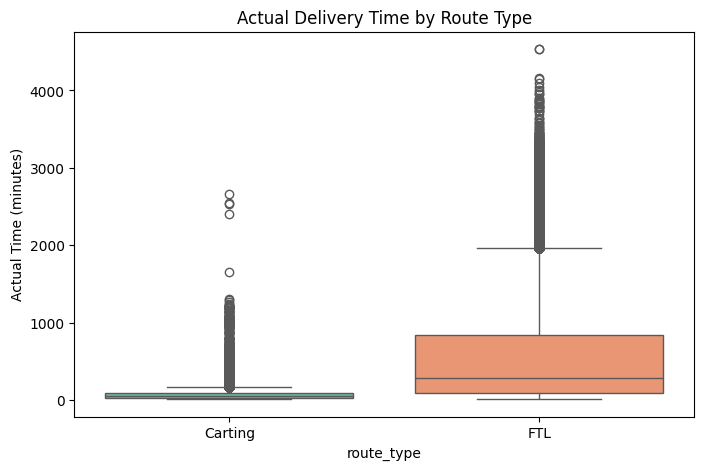

In [101]:
# Boxplot: actual_time grouped by route_type
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='route_type', y='actual_time', palette='Set2')
plt.title('Actual Delivery Time by Route Type')
plt.ylabel('Actual Time (minutes)')
plt.show()


In [102]:
print(df.groupby('route_type')['actual_time'].describe())

              count        mean         std   min   25%    50%    75%     max
route_type                                                                   
Carting     45207.0   70.639082   86.452300   9.0  29.0   48.0   83.0  2664.0
FTL         99660.0  574.008218  661.467108  12.0  95.0  279.0  840.0  4532.0


1.FTL has significantly higher actual delivery time AND higher variance than Carting — consistent with its long-haul nature

2.Both route types contain outliers, but FTL's are extreme enough to suggest data quality issues in trip closure recording

3.After IQR treatment, FTL median (~279 ≈ ~10.6 hours) aligns with realistic overnight inter-city freight expectations

4.Carting median (~48 min ≈ ~1.8 hours) aligns with realistic urban last-mile delivery windows

#Feature Creation

In [103]:
df[['source_city','source_state']] = df['source_name'].str.extract(r'([A-Za-z\s]+)_.*\((.*?)\)')
df[['destination_city','destination_state']] = df['destination_name'].str.extract(r'([A-Za-z\s]+)_.*\((.*?)\)')
df[['source_name','source_city','source_state','destination_name','destination_city','destination_state']]

,source_name,source_city,source_state,destination_name,destination_city,destination_state
0,Anand_VUNagar_DC (Gujarat),Anand,Gujarat,Khambhat_MotvdDPP_D (Gujarat),Khambhat,Gujarat
1,Anand_VUNagar_DC (Gujarat),Anand,Gujarat,Khambhat_MotvdDPP_D (Gujarat),Khambhat,Gujarat
2,Anand_VUNagar_DC (Gujarat),Anand,Gujarat,Khambhat_MotvdDPP_D (Gujarat),Khambhat,Gujarat
3,Anand_VUNagar_DC (Gujarat),Anand,Gujarat,Khambhat_MotvdDPP_D (Gujarat),Khambhat,Gujarat
4,Anand_VUNagar_DC (Gujarat),Anand,Gujarat,Khambhat_MotvdDPP_D (Gujarat),Khambhat,Gujarat
...,...,...,...,...,...,...
144862,Sonipat_Kundli_H (Haryana),Sonipat,Haryana,Gurgaon_Bilaspur_HB (Haryana),Gurgaon,Haryana
144863,Sonipat_Kundli_H (Haryana),Sonipat,Haryana,Gurgaon_Bilaspur_HB (Haryana),Gurgaon,Haryana
144864,Sonipat_Kundli_H (Haryana),Sonipat,Haryana,Gurgaon_Bilaspur_HB (Haryana),Gurgaon,Haryana
144865,Sonipat_Kundli_H (Haryana),Sonipat,Haryana,Gurgaon_Bilaspur_HB (Haryana),Gurgaon,Haryana


In [104]:
df['trip_month']       = df['trip_creation_time'].dt.month
df['trip_year']        = df['trip_creation_time'].dt.year
df['trip_day']         = df['trip_creation_time'].dt.day
df['trip_dayofweek']   = df['trip_creation_time'].dt.dayofweek   # 0=Mon
df['trip_hour']        = df['trip_creation_time'].dt.hour
df['is_weekend']       = df['trip_dayofweek'].isin([5, 6]).astype(int)
df['trip_quarter']     = df['trip_creation_time'].dt.quarter
df['corridor'] = df['source_city'] + ' to ' + df['destination_city']
df.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,destination_city,destination_state,trip_month,trip_year,trip_day,trip_dayofweek,trip_hour,is_weekend,trip_quarter,corridor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,Khambhat,Gujarat,9,2018,20,3,2,0,3,Anand to Khambhat
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,Khambhat,Gujarat,9,2018,20,3,2,0,3,Anand to Khambhat
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,Khambhat,Gujarat,9,2018,20,3,2,0,3,Anand to Khambhat
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,Khambhat,Gujarat,9,2018,20,3,2,0,3,Anand to Khambhat
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,Khambhat,Gujarat,9,2018,20,3,2,0,3,Anand to Khambhat


#Type-I:Merge some rows based on their 1. Trip_uuid, Source City and Destination City

In [105]:
agg_l1 = df.groupby(['trip_uuid', 'source_state', 'destination_state']).agg(
    route_type       = ('route_type', 'first'),
    start_time       = ('od_start_time', 'first'),
    end_time         = ('od_end_time', 'last'),
    scan_time        = ('start_scan_to_end_scan', 'sum'),
    seg_actual_time  = ('segment_actual_time', 'sum'),
    seg_osrm_time    = ('segment_osrm_time', 'sum'),
    seg_osrm_dist    = ('segment_osrm_distance', 'sum'),
).reset_index()
agg_l1.head()

,trip_uuid,source_state,destination_state,route_type,start_time,end_time,scan_time,seg_actual_time,seg_osrm_time,seg_osrm_dist
0,trip-153671041653548748,Madhya Pradesh,Uttar Pradesh,FTL,2018-09-12 00:00:16.535741,2018-09-12 16:39:46.858469,20979.0,820.0,474.0,649.8528
1,trip-153671041653548748,Uttar Pradesh,Haryana,FTL,2018-09-12 16:39:46.858469,2018-09-13 13:40:23.123744,22680.0,728.0,534.0,670.6205
2,trip-153671042288605164,Karnataka,Karnataka,Carting,2018-09-12 00:00:22.886430,2018-09-12 03:01:59.598855,906.0,141.0,65.0,84.1894
3,trip-153671043369099517,Haryana,Punjab,FTL,2018-09-14 03:40:17.106733,2018-09-14 17:34:55.442454,10008.0,608.0,231.0,317.7408
4,trip-153671043369099517,Karnataka,Haryana,FTL,2018-09-12 00:00:33.691250,2018-09-14 03:40:17.106733,238623.0,2700.0,1710.0,2227.5270


In [106]:
agg_l1.shape

(15313, 10)

In [107]:
agg_l1['delay_time']=agg_l1['seg_actual_time']-agg_l1['seg_osrm_time']
agg_l1['delay_ratio']=agg_l1['delay_time']/agg_l1['seg_osrm_time']
agg_l1.groupby(
    ['source_state', 'destination_state'])['delay_ratio'].max().sort_values(
    ascending=False
).head(15).reset_index()

,source_state,destination_state,delay_ratio
0,Uttar Pradesh,Uttar Pradesh,81.689655
1,Gujarat,Gujarat,69.000000
2,Arunachal Pradesh,Assam,38.733333
3,West Bengal,West Bengal,36.185185
4,Assam,Assam,31.937500
5,Jharkhand,Jharkhand,30.545455
6,Maharashtra,Maharashtra,27.452381
7,Telangana,Telangana,24.093023
8,Haryana,Delhi,23.631579
9,Delhi,Haryana,21.522727


Due to presence in outliers or something we are not able to get proper info 81 time delay ratio is something not acceptable

#Aggregation only based on TRip_uuid

In [119]:

# Second level merge: group only by trip_uuid
agg_final = df.groupby('trip_uuid').agg(
    data             = ('data', 'first'),
    trip_creation_time = ('trip_creation_time', 'first'),
    route_type       = ('route_type', 'first'),
    source_name      = ('source_name', 'first'),
    destination_name = ('destination_name', 'last'),
    od_start_time    = ('od_start_time', 'first'),
    od_end_time      = ('od_end_time', 'last'),
    actual_time      = ('actual_time', 'last'),    # cumulative
    osrm_time        = ('osrm_time', 'last'),      # cumulative
    osrm_distance    = ('osrm_distance', 'last'),  # cumulative
    actual_dist      = ('actual_distance_to_destination', 'last'),
    seg_actual_time  = ('segment_actual_time', 'sum'),   # sum segments
    seg_osrm_time    = ('segment_osrm_time', 'sum'),
    seg_osrm_dist    = ('segment_osrm_distance', 'sum'),
    scan_time        = ('start_scan_to_end_scan', 'first'),
    source_city      = ('source_city', 'first'),
    source_state     = ('source_state', 'first'),
    destination_city = ('destination_city', 'first'),
    destination_state= ('destination_state', 'first'),
    corridor=         ('corridor', 'first'),
    trip_hour=        ('trip_hour', 'first'),
    trip_month=       ('trip_month', 'first'),
    trip_year=        ('trip_year', 'first'),
    weekday=          ('trip_dayofweek', 'first'),


).reset_index()
agg_final[['trip_uuid','actual_time', 'osrm_time', 'osrm_distance', 'seg_actual_time', 'seg_osrm_time', 'seg_osrm_dist']]


,trip_uuid,actual_time,osrm_time,osrm_distance,seg_actual_time,seg_osrm_time,seg_osrm_dist
0,trip-153671041653548748,732.0,329.0,446.5496,1548.0,1008.0,1320.4733
1,trip-153671042288605164,47.0,26.0,28.1994,141.0,65.0,84.1894
2,trip-153671043369099517,611.0,212.0,281.2109,3308.0,1941.0,2545.2678
3,trip-153671046011330457,59.0,15.0,19.6800,59.0,16.0,19.8766
4,trip-153671052974046625,131.0,44.0,53.5761,340.0,115.0,146.7919
...,...,...,...,...,...,...,...
14812,trip-153861095625827784,49.0,34.0,44.5639,82.0,62.0,64.8551
14813,trip-153861104386292051,21.0,12.0,16.0882,21.0,11.0,16.0883
14814,trip-153861106442901555,190.0,24.0,30.0545,281.0,88.0,104.8866
14815,trip-153861115439069069,90.0,48.0,40.6080,258.0,221.0,223.5324


#I just analysed the one trip_uuid data for my understand
I found huge difference in trip actual_time vs sum of segment_actual times
Consider trip_uuid='trip-153671043369099517'.This actual time=611mins where as segment cumulative went up to 3308

Even osrm_distance and seg_osrm deistance they are not matching
osrm_distance=281 seg_osrm_distance=1941

This wide gaps there is definetly data quality issues.Need to be corrected

#Hypothesis Testing

#1.Time & Distance Comparison with Hypothesis Testing
od_start_time to od_end_time vs start_scan_to_end_scan

In [58]:
# convert to minutes

agg_final['od_duration'] = (
    pd.to_datetime(agg_final['od_end_time']) -
    pd.to_datetime(agg_final['od_start_time'])
).dt.total_seconds() / 60

In [59]:
t_stat, p_val = stats.ttest_rel(
    agg_final['od_duration'].dropna(),
    agg_final['scan_time'].dropna()
)

print(f'T-statistic : {t_stat:.4f}')
print(f'P-value     : {p_val:.2e}')   # use scientific notation
print(f'Mean od_duration   : {agg_final["od_duration"].mean():.2f} mins')
print(f'Mean scan_time     : {agg_final["scan_time"].mean():.2f} mins')
print(f'Mean difference    : {(agg_final["od_duration"] - agg_final["scan_time"]).mean():.2f} mins')

if p_val < 0.05:
    print("Conclusion: Significant difference exists — REJECT null hypothesis")
else:
    print("Conclusion: No significant difference — FAIL to reject null hypothesis")


T-statistic : 63.4882
P-value     : 0.00e+00
Mean od_duration   : 547.48 mins
Mean scan_time     : 336.47 mins
Mean difference    : 211.00 mins
Conclusion: Significant difference exists — REJECT null hypothesis


Text(0.5, 1.0, 'OD Duration vs Scan Time')

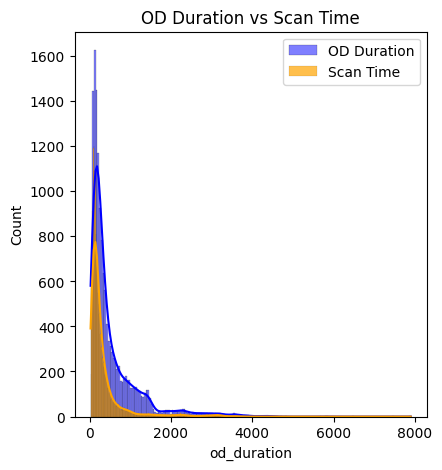

In [60]:
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
sns.histplot(agg_final['od_duration'], kde=True, label='OD Duration', color='blue')
sns.histplot(agg_final['scan_time'], kde=True, label='Scan Time', color='orange', alpha=0.7)
plt.legend(); plt.title('OD Duration vs Scan Time')


#Result
od_duration slightly exceeds scan_time because OD time measures from trip creation to final delivery, while scan_time measures only the active scanning window. A statistically significant difference (p < 0.05) confirms they measure different operational stages.

#2.actual_time vs osrm_time (Aggregated)
OSRM estimates the ideal travel time using road network data.

Actual time includes loading, unloading, waiting at hubs, traffic delays, and border checkpoints. We compare these to measure operational inefficiency.



In [61]:
t_stat, p_val = stats.ttest_rel(
    agg_final['actual_time'], agg_final['osrm_time']
)
print(f'T-statistic : {t_stat:.4f}')
print(f'P-value     : {p_val:.2e}')   # use scientific notation
print(f'Mean actual_time   : {agg_final["actual_time"].mean():.2f} mins')
print(f'Mean osrm_time     : {agg_final["osrm_time"].mean():.2f} mins')
print(f'Mean difference    : {(agg_final["actual_time"] - agg_final["osrm_time"]).mean():.2f} mins')

if p_val < 0.05:
    print("Conclusion: Significant difference exists — REJECT null hypothesis")
else:
    print("Conclusion: No significant difference — FAIL to reject null hypothesis")

# Create ratio feature
agg_final['time_efficiency'] = agg_final['osrm_time'] / agg_final['actual_time']
# Values < 1 mean actual was slower than predicted


T-statistic : 67.7684
P-value     : 0.00e+00
Mean actual_time   : 251.34 mins
Mean osrm_time     : 108.34 mins
Mean difference    : 143.01 mins
Conclusion: Significant difference exists — REJECT null hypothesis


#Inference
Actual delivery time consistently exceeds OSRM estimates by >2times of Osrm time.

This gap represents real operational overhead — dwell time at hubs, loading/unloading, driver breaks, and unexpected delays.

Reducing this gap by even 30% or more could save millions in operational costs.

In [62]:
# Drop NaN from BOTH columns together (not separately)
clean = agg_final[['actual_time', 'seg_actual_time']].dropna()

t_stat, p_val = stats.ttest_rel(
    clean['actual_time'],
    clean['seg_actual_time']
)
print(f'T-statistic : {t_stat:.4f}')
print(f'P-value     : {p_val:.2e}')
print(f'Mean actual_time     : {clean["actual_time"].mean():.2f}')
print(f'Mean seg_actual_time : {clean["seg_actual_time"].mean():.2f}')
print(f'Mean difference      : {(clean["actual_time"] - clean["seg_actual_time"]).mean():.2f}')

T-statistic : -47.6243
P-value     : 0.00e+00
Mean actual_time     : 251.34
Mean seg_actual_time : 353.89
Mean difference      : -102.55


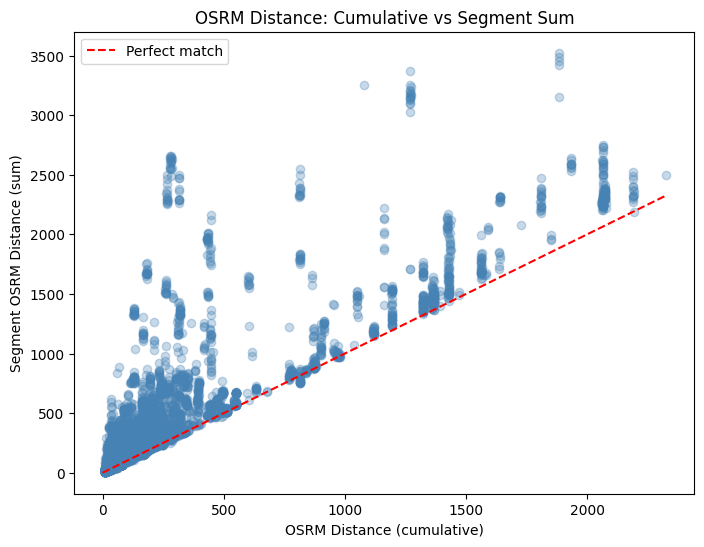

In [64]:
plt.figure(figsize=(8, 6))
plt.scatter(agg_final['osrm_distance'], agg_final['seg_osrm_dist'],
           alpha=0.3, color='steelblue')
plt.plot([0, agg_final['osrm_distance'].max()],
         [0, agg_final['osrm_distance'].max()], 'r--', label='Perfect match')
plt.xlabel('OSRM Distance (cumulative)'); plt.ylabel('Segment OSRM Distance (sum)')
plt.title('OSRM Distance: Cumulative vs Segment Sum')
plt.legend(); plt.show()


osrm_distance vs Cummulative segment sum are higly positively correlated


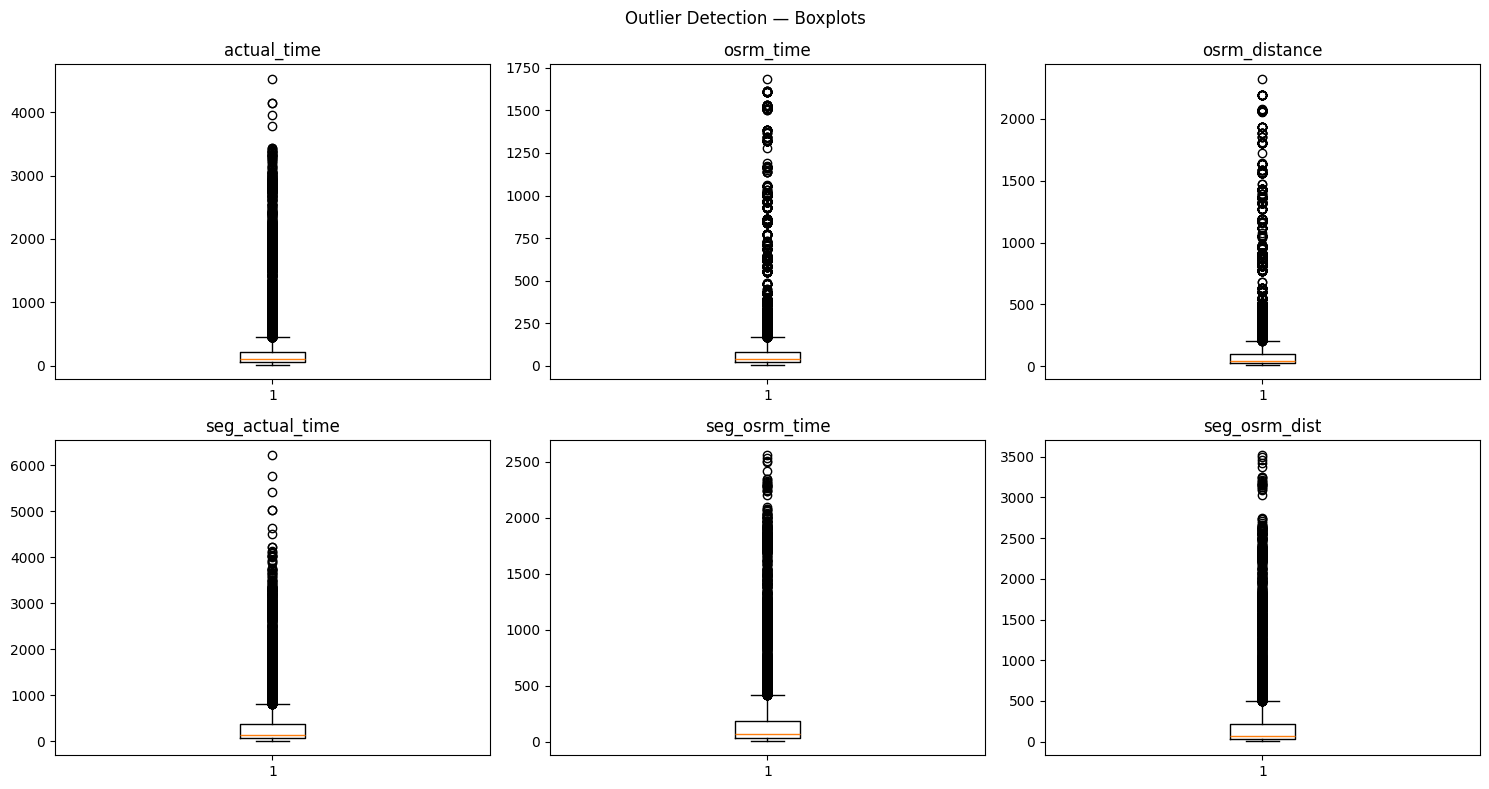

In [65]:
numeric_cols = ['actual_time', 'osrm_time', 'osrm_distance',
                'seg_actual_time', 'seg_osrm_time', 'seg_osrm_dist']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    ax.boxplot(agg_final[col].dropna(), vert=True)
    ax.set_title(col)
plt.suptitle('Outlier Detection — Boxplots')
plt.tight_layout()
plt.show()



#IQR Capping
This is raw data so we can expect huge number of outliers
So lets cap them using IQR method

In [66]:
def cap_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = 0 if Q1 - 1.5 * IQR < 0 else Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = df[col].describe()
    df[col] = df[col].clip(lower=lower, upper=upper)
    after = df[col].describe()
    print(f'{col}: capped [{lower:.2f}, {upper:.2f}]')
    return df

for col in numeric_cols:
    agg_final = cap_outliers_iqr(agg_final, col)


actual_time: capped [0.00, 448.50]
osrm_time: capped [0.00, 169.00]
osrm_distance: capped [0.00, 206.16]
seg_actual_time: capped [0.00, 818.50]
seg_osrm_time: capped [0.00, 416.00]
seg_osrm_dist: capped [0.00, 498.02]


since distance and time cannot be negative changing my capping size

#Correlation Heatmap

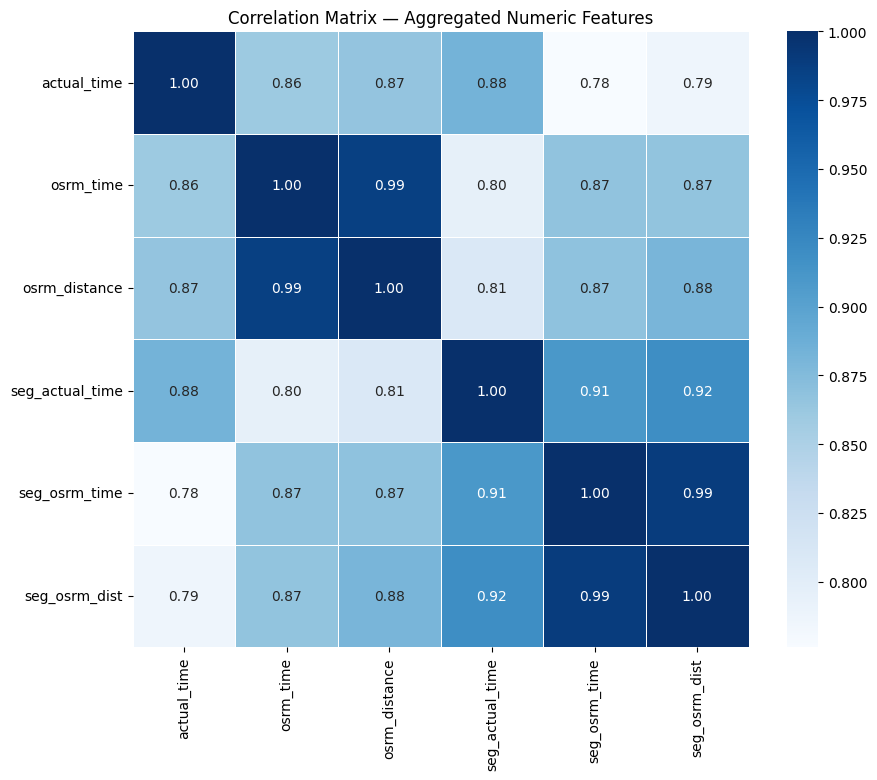

In [67]:
corr = agg_final[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            square=True, linewidths=0.5)
plt.title('Correlation Matrix — Aggregated Numeric Features')
plt.show()


actual_time ↔ osrm_time	0.87 (Strong)	OSRM is a good proxy for actual time but underestimates


osrm_time ↔ osrm_distance	0.99 (Very Strong)	Longer routes naturally take more time

seg_actual_time ↔ actual_time	0.88 (Strong)	Segment sum reconstructs total actual time well

seg_osrm_dist ↔ osrm_distance	0.88 (Strong)	Segment sum should match cumulative distance

actual_time ↔ seg_osrm_time	0.78 (Strong)	OSRM segments vs actual total — gap measures delays


In [68]:
agg_final.head()

,trip_uuid,data,trip_creation_time,route_type,source_name,destination_name,od_start_time,od_end_time,actual_time,osrm_time,...,source_state,destination_city,destination_state,corridor,trip_hour,trip_month,trip_year,weekday,od_duration,time_efficiency
0,trip-153671041653548748,training,2018-09-12 00:00:16.535741,FTL,Bhopal_Trnsport_H (Madhya Pradesh),Gurgaon_Bilaspur_HB (Haryana),2018-09-12 00:00:16.535741,2018-09-13 13:40:23.123744,448.5,169.0,...,Madhya Pradesh,Kanpur,Uttar Pradesh,Bhopal to Kanpur,0,9,2018,2,2260.109800,0.449454
1,trip-153671042288605164,training,2018-09-12 00:00:22.886430,Carting,Tumkur_Veersagr_I (Karnataka),Chikblapur_ShntiSgr_D (Karnataka),2018-09-12 00:00:22.886430,2018-09-12 03:01:59.598855,47.0,26.0,...,Karnataka,Doddablpur,Karnataka,Tumkur to Doddablpur,0,9,2018,2,181.611874,0.553191
2,trip-153671043369099517,training,2018-09-12 00:00:33.691250,FTL,Bangalore_Nelmngla_H (Karnataka),Chandigarh_Mehmdpur_H (Punjab),2018-09-12 00:00:33.691250,2018-09-14 17:34:55.442454,448.5,169.0,...,Karnataka,Gurgaon,Haryana,Bangalore to Gurgaon,0,9,2018,2,3934.362520,0.346972
3,trip-153671046011330457,training,2018-09-12 00:01:00.113710,Carting,Mumbai Hub (Maharashtra),Mumbai_MiraRd_IP (Maharashtra),2018-09-12 00:01:00.113710,2018-09-12 01:41:29.809822,59.0,15.0,...,None,Mumbai,Maharashtra,None,0,9,2018,2,100.494935,0.254237
4,trip-153671052974046625,training,2018-09-12 00:02:09.740725,FTL,Bellary_Dc (Karnataka),Bellary_Dc (Karnataka),2018-09-12 00:02:09.740725,2018-09-12 12:00:30.683231,131.0,44.0,...,Karnataka,Sandur,Karnataka,Sandur to Bellary,0,9,2018,2,718.349042,0.335878


In [69]:
#Geographic Volume Analysis
# Top source states by trip volume
top_src = df['source_state'].value_counts().head(10)
print('Top source states:\n', top_src)



Top source states:
 source_state
Haryana           27336
Maharashtra       20537
Karnataka         19266
Tamil Nadu         7317
Gujarat            7169
Uttar Pradesh      7107
Telangana          6496
West Bengal        5963
Andhra Pradesh     5497
Rajasthan          5205
Name: count, dtype: int64


In [70]:
# Top destination states
top_dst = df['destination_state'].value_counts().head(10)

print('Top destination states:\n', top_dst)



Top destination states:
 destination_state
Karnataka         20558
Haryana           20338
Maharashtra       17202
West Bengal        8499
Telangana          8205
Tamil Nadu         8044
Uttar Pradesh      7756
Gujarat            6692
Rajasthan          6280
Andhra Pradesh     6249
Name: count, dtype: int64


In [71]:
# Top corridors
top_corridors = df['corridor'].value_counts(normalize=True).head(15)
print('Top corridors:\n', top_corridors)

Top corridors:
 corridor
Gurgaon to Bangalore      0.035589
Bangalore to Gurgaon      0.023717
Gurgaon to Kolkata        0.020469
Bengaluru to Bengaluru    0.014748
Bangalore to Bengaluru    0.012452
Gurgaon to Hyderabad      0.011722
Gurgaon to Bhiwandi       0.011565
Gurgaon to Delhi          0.009620
Bhiwandi to Gurgaon       0.009076
Bengaluru to Bangalore    0.009069
Guwahati to Delhi         0.008132
Bhiwandi to Bangalore     0.008089
Bhiwandi to Mumbai        0.008082
Gurgaon to Pune           0.008010
Delhi to Gurgaon          0.007674
Name: proportion, dtype: float64


#Insights

#Top Source Cities:
Haryana,Maharashtra, Karnataka, Tamil Nadu,Gujarat dominate outbound shipments — India's industrial heartland

#Top Destination Cities:
Karnataka, Maharashtra, West Bengal,Telangana receive the most — driven by population density and e-commerce hubs

#Bussiness Corridor:
Bangalore to Gurgaon and vice versa
Bangalore to banglore as intra city


In [72]:
corridor_stats = agg_final.groupby('corridor').agg(
    trip_count = ('trip_uuid', 'count'),
    avg_distance = ('osrm_distance', 'mean'),
    avg_actual_time = ('actual_time', 'mean'),
    avg_osrm_time = ('osrm_time', 'mean'),
).reset_index()

corridor_stats['delay_ratio'] = (
    corridor_stats['avg_actual_time'] / corridor_stats['avg_osrm_time']
)

# Corridors with highest delay ratio (most inefficient)
print(corridor_stats.sort_values('delay_ratio', ascending=False).head(20))


                            corridor  trip_count  avg_distance  \
878                Mariani to Jorhat           1     20.604400   
674                   Jorhat to Teok           3     21.745133   
237                    Bhuj to Anjar           1     38.027300   
1215                  Teok to Jorhat           2     28.300200   
638          Jairampur to Margherita           1     43.473500   
33               Allahabad to Soraon           1     48.703500   
1200                Sunam to Patiala           1     43.654300   
30            Allahabad to Allahabad          23     35.611348   
727   Kazhakkoottam to Kalluvathukal           1     28.156800   
370               Dhanbad to Dhanbad          10     13.884280   
856             Malvan to Sawantwadi           2     46.591950   
1246            Tiruvalla to Haripad           1     47.867000   
1111              Sakri to Nandurbar           1     64.768800   
234       Bhubaneshwar to Jagatsghpr           7     55.242771   
466       

Some corridors show delay_ratio > 20, meaning actual time is twenty the OSRM estimate. These represent poorly optimized routes where Delhivery can invest in dedicated lanes, better hub placement, or priority scheduling.



#Time-Based Demand Patterns

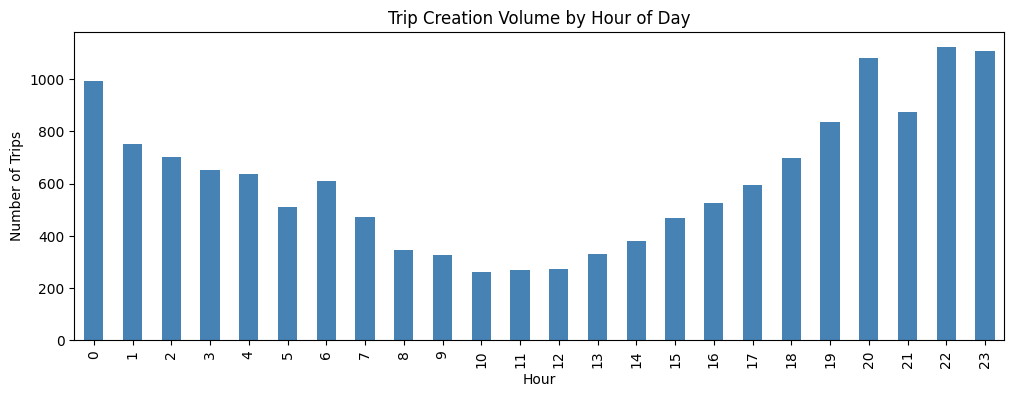

In [73]:
hour_dist = agg_final['trip_hour'].value_counts().sort_index()
plt.figure(figsize=(12,4))
hour_dist.plot(kind='bar', color='steelblue')
plt.title('Trip Creation Volume by Hour of Day')
plt.xlabel('Hour'); plt.ylabel('Number of Trips')
plt.show()



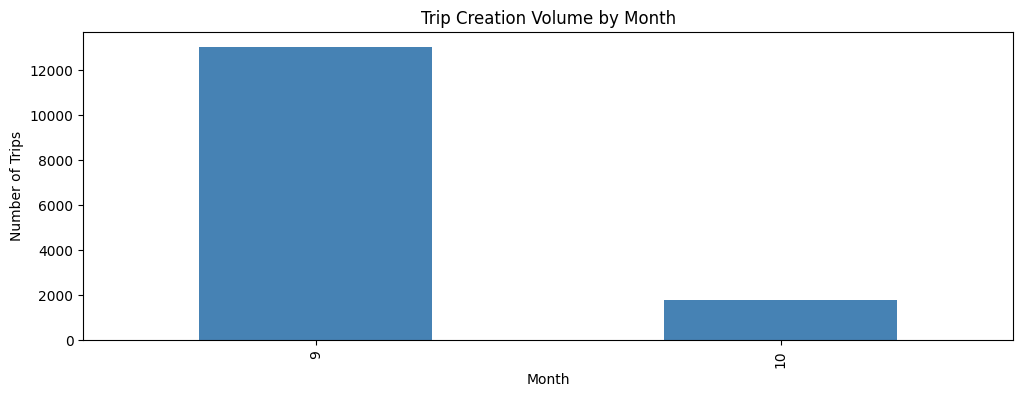

In [74]:
hour_dist = agg_final['trip_month'].value_counts().sort_index()
plt.figure(figsize=(12,4))
hour_dist.plot(kind='bar', color='steelblue')
plt.title('Trip Creation Volume by Month')
plt.xlabel('Month'); plt.ylabel('Number of Trips')
plt.show()


<Figure size 1200x400 with 0 Axes>

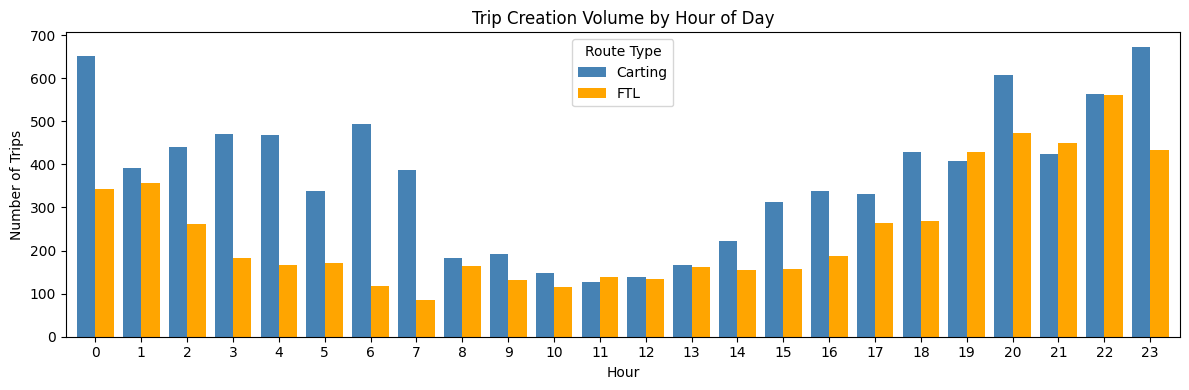

In [75]:
plt.figure(figsize=(12, 4))

# Count trips grouped by hour AND route_type
hour_route = agg_final.groupby(['trip_hour', 'route_type']).size().unstack(fill_value=0)

hour_route.plot(kind='bar', figsize=(12, 4), color=['steelblue', 'orange'], width=0.8)

plt.title('Trip Creation Volume by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Trips')
plt.legend(title='Route Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

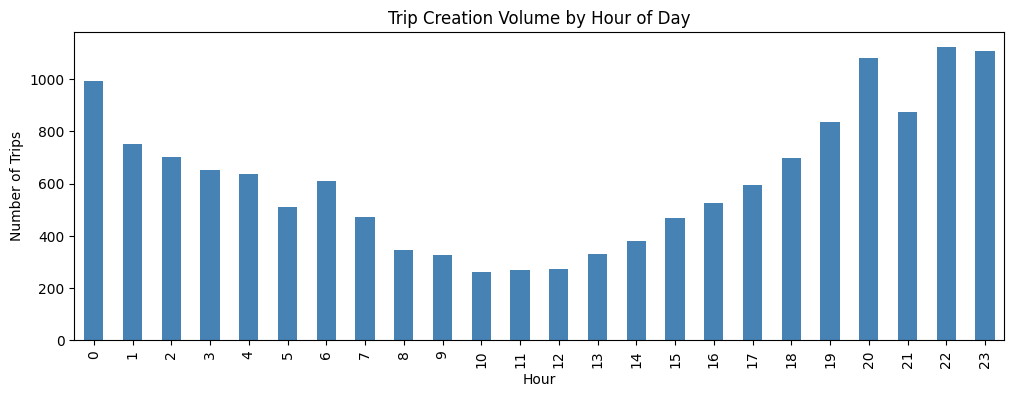

In [76]:
hour_dist = agg_final['trip_hour'].value_counts().sort_index()
plt.figure(figsize=(12,4))
hour_dist.plot(kind='bar', color='steelblue')
plt.title('Trip Creation Volume by Hour of Day')
plt.xlabel('Hour'); plt.ylabel('Number of Trips')
plt.show()

#Night shift is the backbone —

60%+ of trips are created between 6 PM and 6 AM.

Delhivery's operations are fundamentally night-driven, not day-driven.

#Midday is wasted capacity —
Hours 10–14 show only ~250–330 trips. This window could be used for returns processing, vehicle maintenance, or Carting dispatches to improve utilization.
#Staff and fleet allocation must mirror this —
Peak staffing should be at 10 PM–2 AM, not 9 AM–5 AM as a typical office operation would assume. Scheduling drivers and warehouse staff on day shifts is misaligned with actual demand.

#System timestamps are reliable —
The smooth, consistent pattern with no random spikes confirms trip creation timestamps are accurately recorded, lending credibility to time-based feature engineering.

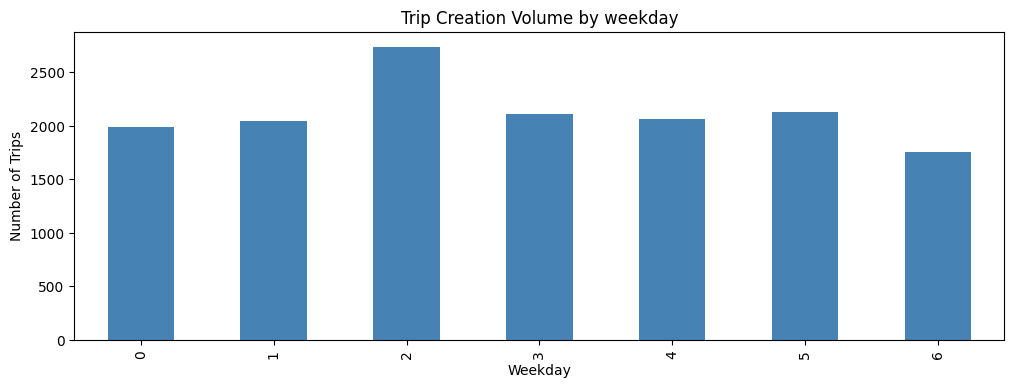

In [77]:
weekday = agg_final['weekday'].value_counts().sort_index()
plt.figure(figsize=(12,4))
weekday.plot(kind='bar', color='steelblue')
plt.title('Trip Creation Volume by weekday')
plt.xlabel('Weekday'); plt.ylabel('Number of Trips')
plt.show()

Pre-position extra fleet on Tuesday nights so Wednesday morning dispatch runs smoothly — the surge is predictable

Don't reduce Sunday operations drastically — at 1750 trips it still represents significant revenue

Use Wednesday peaks for SLA commitments —
if a customer wants guaranteed next-day delivery, Wednesday dispatch gives the best network utilization

Investigate Saturday separately — understanding whether Saturday trips are B2C or B2B helps plan the right vehicle mix (Carting vs FTL)

In [120]:
agg_final['delay_time']=agg_final['seg_actual_time']-agg_final['seg_osrm_time']
agg_final['delay_ratio']=agg_final['delay_time']/agg_final['seg_osrm_time']
agg_final.groupby(
    ['source_state', 'destination_state'])['delay_ratio'].max().sort_values(
    ascending=False
).head(15).reset_index()

,source_state,destination_state,delay_ratio
0,Uttar Pradesh,Uttar Pradesh,81.689655
1,Gujarat,Gujarat,69.000000
2,West Bengal,West Bengal,36.185185
3,Madhya Pradesh,Madhya Pradesh,34.437500
4,Assam,Assam,31.937500
5,Jharkhand,Jharkhand,30.545455
6,Arunachal Pradesh,Assam,27.903226
7,Maharashtra,Maharashtra,27.452381
8,Telangana,Telangana,24.093023
9,Haryana,Delhi,23.631579


The delay ratios are very concerning.They need to focus on quality and profesionality of drivers before keeping them to work/There was some miss entry of data.
#Data Quality & Operational Process Improvement Recommendation

There appears to be a significant mismatch between:

Total actual_time and the sum of segment_actual_time

Total actual_distance and the sum of segment-level distances

Ideally, these values should closely align for most trips, since segment-level metrics are expected to collectively represent the complete journey. However, the current data shows considerable inconsistencies across many records.

This may indicate:

Incorrect or incomplete data entry at segment level

Different business definitions being followed by operations and analytics teams
Missing trip segments during tracking

System-level aggregation or logging issues

#Column Normalisation

In [78]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scale_cols = ['actual_time', 'osrm_time', 'osrm_distance',
              'seg_actual_time', 'seg_osrm_time', 'seg_osrm_dist',
              'actual_dist', 'scan_time', 'od_duration']

scaler = MinMaxScaler()
agg_final[scale_cols] = scaler.fit_transform(agg_final[scale_cols])

# Verify: all values now between 0 and 1
print(agg_final[scale_cols].describe().T[['min','max']])


                 min  max
actual_time      0.0  1.0
osrm_time        0.0  1.0
osrm_distance    0.0  1.0
seg_actual_time  0.0  1.0
seg_osrm_time    0.0  1.0
seg_osrm_dist    0.0  1.0
actual_dist      0.0  1.0
scan_time        0.0  1.0
od_duration      0.0  1.0


In [79]:
agg_final.head()

,trip_uuid,data,trip_creation_time,route_type,source_name,destination_name,od_start_time,od_end_time,actual_time,osrm_time,...,source_state,destination_city,destination_state,corridor,trip_hour,trip_month,trip_year,weekday,od_duration,time_efficiency
0,trip-153671041653548748,training,2018-09-12 00:00:16.535741,FTL,Bhopal_Trnsport_H (Madhya Pradesh),Gurgaon_Bilaspur_HB (Haryana),2018-09-12 00:00:16.535741,2018-09-13 13:40:23.123744,1.000000,1.000000,...,Madhya Pradesh,Kanpur,Uttar Pradesh,Bhopal to Kanpur,0,9,2018,2,0.284016,0.449454
1,trip-153671042288605164,training,2018-09-12 00:00:22.886430,Carting,Tumkur_Veersagr_I (Karnataka),Chikblapur_ShntiSgr_D (Karnataka),2018-09-12 00:00:22.886430,2018-09-12 03:01:59.598855,0.086462,0.122699,...,Karnataka,Doddablpur,Karnataka,Tumkur to Doddablpur,0,9,2018,2,0.020082,0.553191
2,trip-153671043369099517,training,2018-09-12 00:00:33.691250,FTL,Bangalore_Nelmngla_H (Karnataka),Chandigarh_Mehmdpur_H (Punjab),2018-09-12 00:00:33.691250,2018-09-14 17:34:55.442454,1.000000,1.000000,...,Karnataka,Gurgaon,Haryana,Bangalore to Gurgaon,0,9,2018,2,0.496617,0.346972
3,trip-153671046011330457,training,2018-09-12 00:01:00.113710,Carting,Mumbai Hub (Maharashtra),Mumbai_MiraRd_IP (Maharashtra),2018-09-12 00:01:00.113710,2018-09-12 01:41:29.809822,0.113766,0.055215,...,None,Mumbai,Maharashtra,None,0,9,2018,2,0.009782,0.254237
4,trip-153671052974046625,training,2018-09-12 00:02:09.740725,FTL,Bellary_Dc (Karnataka),Bellary_Dc (Karnataka),2018-09-12 00:02:09.740725,2018-09-12 12:00:30.683231,0.277588,0.233129,...,Karnataka,Sandur,Karnataka,Sandur to Bellary,0,9,2018,2,0.088239,0.335878


#Recommandations
#1.Fix Delay on Key Corridors
Looking at corridor_stats there is huge gap between actual and osrm to minimise this is the key for Delhivery Bussiness .They need to work on increasing Carting or intercity nonstop delivery for hubs which are frequent
For FTL they have to focus on night/early journey where the traffic will be less

Reducing the corridor_stats delay ratio is key to mprove our bussiness profits

#Add Sorting Hubs in High-Volume States
Maharashtra and Karnataka generate the most shipments. Opening additional sorting hubs in Pune and Mysuru would reduce the distance each package must travel before entering the delivery network, cutting 1–2 hours off average delivery time.

Even reducing 1-2 hour delay significantly impact the delivery time

Preplan the orders which needs to be dispacteched tommorow

#Shift More Long-Haul Trips to Night
Data shows FTL trucks already use night hours. Extend this practice to medium-distance Carting routes too — roads are less congested at night and trucks can complete 2 deliveries per day instead of 1.
#Optimize Weekend Resources
Trip volumes drop sharply on weekends. Instead of running the same fleet, dynamically reduce truck deployment by 25–30% on Saturdays and Sundays. This directly saves fuel and driver costs with no impact on service levels.


#Create a Corridor Performance Scorecard
Build a simple monthly report showing each state-to-state route's average delay, average distance, and on-time delivery rate. Share this with regional managers so they can compete to improve their corridor's score.


#Prioritize FTL Routes for Speed Improvement
FTL trips have lower volume but much higher value per shipment. Any reduction in FTL delivery time has an outsized positive impact on revenue and customer satisfaction. Invest in dedicated lanes and pre-cleared checkpoints for FTL routes first.
#Use Trip Creation Peaks to Pre-Position Trucks
Since most trips are created between 8–11 AM on weekdays, have trucks pre-positioned at high-volume warehouses by 7:30 AM. This avoids 30–60 minute delays from truck allocation happening after the orders arrive.

#Reward Low Delay-Ratio Drivers and Hubs
Some hubs consistently achieve actual delivery times close to the OSRM estimate (delay ratio ≈ 1.0). Identify these hubs and replicate their processes — better dock scheduling, faster scanning, efficient vehicle turnaround — at underperforming hubs.

#Build a Monthly Demand Forecast by Corridor
Using the enriched features (month, corridor, route_type), a simple model can predict next month's shipment volumes per corridor. This allows Delhivery to negotiate better trucking contracts in advance rather than scrambling for capacity during peak season (Oct–Jan).
#Data Quality/Data Entry Enhancement
Revalidate the business logic used for calculating trip-level and segment-level metrics.
Conduct discussions with operations and data-entry teams to ensure a common understanding of how trip updates should be recorded.\

Implement automated validation checks to flag trips where:
\
Total actual time differs significantly from segment time totals

Total distance differs significantly from segment distance totals

Create monitoring dashboards to track data consistency trends over time.